# Case Study 1: EOT FDFI Data Analysis Pipeline

This notebook implements the Section 4 case-study workflow for the `sens50` HIV neutralization data. The goal is to turn the processed data object into a reproducible FDFI analysis: load the feature matrix and biological feature groups, fit a black-box prediction model, initialize `EOTExplainer`, compute feature-level inference in both original and latent spaces, and prepare group-level summaries and visualization inputs.

The notebook is intended to be read as an analysis companion rather than as a raw execution log. Each block explains what is being computed and how to interpret the output. Visualization and biological interpretation are prepared here but connect to the follow-up discussion in Section 5.


## Imports and environment

We first import the data-processing, modeling, inference, and plotting tools used throughout the notebook. The core FDFI object for this case study is `EOTExplainer`, which is designed for high-dimensional settings where original-space feature perturbations are better handled through an analytical whitening map and entropic optimal-transport coupling moments.

The package version is printed so the notebook output can be traced to a specific `fdfi` build.


In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import fdfi
print(fdfi.__version__)
from fdfi.explainers import EOTExplainer


0.0.6


## Load data and biological feature groups

This block loads the processed `sens50` analysis file and separates the response from the predictor matrix. The dataset has 611 observations, 832 sequence-derived predictors, and 14 biological feature groups in the current processed files.

The `feature_group.csv` file is converted into a feature-by-group indicator matrix and then reindexed to `X.columns`. That alignment step is important because group-level inference later assumes that the rows of `df_groups` correspond exactly to the columns of the model matrix.

Most predictors in this data object are binary or otherwise discrete sequence-derived indicators. The combination of high dimensionality and mostly discrete features is the main reason this notebook uses `EOTExplainer` rather than a flow-Jacobian-based local attribution workflow.


In [2]:
DATA_DIR = Path("data")

DATASETS = {
    "sens50": {
        "file": DATA_DIR / "sens50_processed_dataset.csv",
        "target": "sens50",
    },
    "sens80": {
        "file": DATA_DIR / "sens80_processed_dataset.csv",
        "target": "sens80",
    },
    "ic50": {
        "file": DATA_DIR / "ic50.censored_processed_dataset.csv",
        "target": "ic50.censored",
    },
}

outcome = "sens50"

cfg = DATASETS[outcome]
filename = str(cfg["file"])

data = pd.read_csv(cfg["file"])
y = data[cfg["target"]].astype(int)
X = data.drop(columns=[cfg["target"]])

df_groups = pd.read_csv(DATA_DIR / "feature_group.csv", index_col=0).set_index("feature")
df_groups = pd.get_dummies(df_groups["group"]).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")


Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


The loading output is a compact check of the analysis object. `Dataset shape` reports the number of observations and predictors in `X`; `Target variable` identifies which response column was selected; `Number of groups` gives the number of biological modules represented in `df_groups`; and `Data loaded from` records the processed file used for the run.

## Preprocessing

Before fitting the prediction model, the feature matrix is imputed and standardized. Missing predictor values are filled with the most frequent observed value, which is appropriate for mostly binary/discrete indicators, and all predictors are then placed on a common standardized scale.

The response is also standardized. This keeps the squared-loss residual comparison used by the DFI-style EOT calculation on a stable scale: the counterfactual residuals and original residuals are compared in standardized response units.


In [3]:
print("Data preparation...")

preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    StandardScaler(),
)

X_values = preprocess.fit_transform(X)
y_values = y.values.astype(float)

# Standardize y to N(0,1) to match DFI paper (scale-invariant for z-scores
# but ensures the DFI UEIF formula (y - ỹ)² - (y - ŷ)² works in the same
# unit system as the reference implementation)
y_scaler = StandardScaler()
y_values = y_scaler.fit_transform(y_values.reshape(-1, 1)).ravel()

print("Data preparation finished")
print(f"Feature matrix shape: {X_values.shape}")
print(f"y statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")
print(f"Missing values - X: {np.isnan(X_values).sum()}, y: {np.isnan(y_values).sum()}")


Data preparation...
Data preparation finished
Feature matrix shape: (611, 832)
y statistics: mean=-0.000, std=1.000
Missing values - X: 0, y: 0


The preprocessing output checks three things. `Feature matrix shape` confirms that preprocessing preserved the same observation-by-feature structure. The reported response mean and standard deviation show that `y_values` has been centered and scaled. The missing-value counts confirm that both arrays are ready for the model and the explainer.

## Fit the black-box prediction model

FDFI is applied to a fitted prediction function. Here the black-box model is a `RandomForestRegressor` trained on the full processed dataset. Its role is not to serve as the final biological explanation model; instead, it defines the prediction function whose feature importance is analyzed by FDFI.

The callable `model_fn` wraps the fitted random forest so it can be passed directly to `EOTExplainer`.


In [4]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1,
)
rf.fit(X_values, y_values)
model_fn = lambda X_: rf.predict(X_)
print(f"RandomForestRegressor fitted on full data")
print(f"Train R²: {rf.score(X_values, y_values):.3f}")


RandomForestRegressor fitted on full data
Train R²: 0.705


The model output confirms that the random forest was fit on the full data used in this notebook and reports the in-sample training $R^2$. This is a descriptive fit check for the black-box function; the notebook does not use cross-fitting.

## Initialize `EOTExplainer` and compute EOT FDFI

The `sens50` feature matrix is high-dimensional and mostly binary/discrete, so local smooth perturbations in original feature space can be unstable. `EOTExplainer` avoids relying on a learned decoder Jacobian for original-space attribution. Instead, it uses an analytical whitening map and entropic optimal-transport coupling moments to connect latent-space counterfactual replacements back to original-space feature importance.

The main settings are:

- `nsamples=50`: draws 50 counterfactual resamples per feature.
- `epsilon=0.001`: sets the entropic regularization level for the OT coupling.
- `sampling_method="resample"`: draws counterfactual latent coordinates from the empirical background pool.
- `random_state=0`: fixes sampling for reproducibility.


In [5]:
nsamples_main = 50

start_time = time.time()

fdfi_estimator = EOTExplainer(
    model=model_fn,
    data=X_values,
    nsamples=nsamples_main,
    epsilon=0.001,
    sampling_method="resample",
    random_state=0,
)

eot_results = fdfi_estimator(X_values, y=y_values)

dfi_time = time.time() - start_time

print(f"EOT FDFI completed in {dfi_time:.2f} seconds")
print(f"DFI scores shape: {eot_results['phi_X'].shape}")

np.sum(eot_results["phi_X"]), np.sum(eot_results["phi_Z"])


EOT FDFI completed in 597.77 seconds
DFI scores shape: (832,)


(np.float64(0.7396973904611018), np.float64(0.7396975752008021))

The EOT output reports one attribution value per predictor. `phi_X` contains original-space feature importance, aligned with the 832 columns of `X`; `phi_Z` contains the corresponding latent-space importance. The two printed totals, `sum(phi_X)` and `sum(phi_Z)`, are nearly identical in this run, which is a useful internal consistency check for the attribution decomposition.

## Feature-level inference with `conf_int()`

The next block computes uncertainty summaries for all 832 individual predictors. `target="X"` asks for inference in the original feature space, which is the space of the observed sequence-derived predictors. `target="Z"` asks for inference in the whitened latent coordinate system.

Both calls use a two-sided alternative, the mixture variance-floor method, and automatic practical-margin selection. The full confidence-interval objects contain one row per predictor, so the notebook uses compact package-style summaries below to inspect the main output without printing 832 full rows twice.


In [6]:
ci_X = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

ci_Z = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)


## Feature-level summary output

The X-space summary is the primary feature-level result because it is aligned with the original predictors. The Z-space summary is reported as a complementary latent-coordinate check.

In each summary, `Number of units` should match the number of predictors, `Practical margin` reports the automatically selected threshold for practical significance, and the confidence interval, p-value, and significance code describe uncertainty for each feature. The final line counts how many units are significant under the displayed settings.

Because the biological modules are defined over original predictors, the subsequent group-level analysis focuses on X-space inference.


In [7]:
print("=== X-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

print("\n=== Z-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

=== X-space feature summary ===
Feature Importance Results
Method: EOTExplainer
Number of units: 832
Significance level: 0.05
Alternative: two-sided
Margin method: mixture
Practical margin: 0.0028
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.0011     0.0018    -0.0026     0.0047     0.3314      
              1     0.0013     0.0019    -0.0023     0.0050     0.4123      
              2     0.0016     0.0018    -0.0020     0.0052     0.5027      
              3     0.0003     0.0018    -0.0032     0.0039     0.1639      
              4     0.0005     0.0018    -0.0031     0.0040     0.1935      
              5     0.0007     0.0018    -0.0029     0.0042     0.2342      
              6     0.0004     0.0018    -0.0031     0.0040     0.1831      
              7     0.0004   

## Group-level inference

For biological interpretation, the 832 individual predictors are aggregated into 14 predefined biological modules by passing `df_groups` to the `groups` argument of `conf_int()`. This produces group-level uncertainty summaries in the original feature space.

The grouped analysis uses `threshold_null=True`, which thresholds negative mean feature-level contributions before forming the group null. It also uses a fixed variance floor, a fixed zero margin, a two-sided alternative, and Bonferroni correction across the 14 groups.

The resulting `res_df` object is a tidy group-level results data frame. It stores the group name, importance estimate, standard error, z-score, confidence interval, raw and adjusted p-values, rejection flag, and ranking. The same object is used for the compact summary output and for the visualization preparation below.


In [8]:
res_df = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
    verbose=False,
)
margin_used = res_df.get("margin", 0.0)
zscore = res_df.get("zscore", (res_df["score"] - margin_used) / np.maximum(res_df["se"], 1e-12))
ranking = res_df.get("ranking", pd.Series(zscore).rank(ascending=False, method="first").astype(int).to_numpy())

res_df = pd.DataFrame({
    "group":       res_df["groups"],
    "importance":  res_df["score"],
    "se":          res_df["se"],
    "zscore":      zscore,
    "ci_lower":    res_df["ci_lower"],
    "ci_upper":    res_df["ci_upper"],
    "p_value":     res_df["pvalue"],
    "p_value_adj": res_df.get("pvalue_adj", res_df["pvalue"]),
    "reject_null": res_df["reject_null"],
    "ranking":     ranking,
})


## Compact group-level summary output

This package-style summary is the Section 4 group-level reporting format used in place of a separate LaTeX table. It is meant to replace the earlier Table 8-style presentation with a reproducible console summary generated directly by `fdfi`.

The X-space group summary is the main inferential output because the biological feature groups are defined in original predictor space. The Z-space group summary is printed as a supplemental check using the same grouping matrix.

Read `Estimate` as the group-level mean importance, `Std Err` as its standard error, `CI Lower` and `CI Upper` as the uncertainty interval, `Adj P-val` as the Bonferroni-adjusted p-value, and `Sig` as the package's significance code. Interpret the top groups and the number of significant groups from the current notebook output rather than from older manuscript drafts.

In the current saved run, the X-space group summary reports 10 significant groups out of 14, while the Z-space group summary reports 11 out of 14. The ranked X-space check places `covar`, `pngs_novrc01`, `pngs`, `vrc01`, `esa`, and `cd4bs` among the strongest groups, while `cysteines`, `subtype`, `steric_bulk`, and `geog` are not rejected after Bonferroni correction. These should be read as feature groups associated with the fitted random-forest prediction function, not as causal biological effects.


In [9]:
print("=== X-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)
print("\n=== Z-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)


=== X-space group summary ===
Feature Importance Results
Method: EOTExplainer
Number of units: 14
Significance level: 0.05
Alternative: two-sided
Multiple testing: bonferroni
Margin method: fixed
------------------------------------------------------------------------------
          Group   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
          cd4bs     0.1073     0.0097     0.0883     0.1262     0.0000   ***
          covar     0.2089     0.0161     0.1774     0.2403     0.0000   ***
      cysteines     0.0119     0.0042     0.0037     0.0201     0.0616     *
            esa     0.0983     0.0088     0.0810     0.1156     0.0000   ***
           geog     0.0031     0.0041    -0.0048     0.0111     1.0000      
       geometry     0.0359     0.0050     0.0262     0.0456     0.0000   ***
          glyco     0.0541     0.0058     0.0428     0.0654     0.0000   ***
           gp41     0.0270    

## Biological group labels

The visualization uses compact group numbers on the axes, so this mapping connects each number to its biological annotation. Keeping the labels in a separate data frame makes the plotting code easier to read and provides a reusable legend for the Section 5 visualization panel.


In [10]:
group_mapping = pd.DataFrame({
    "group_num": range(1, 15),
    "group": [
        "vrc01", "cd4bs", "esa", "glyco", "covar", "pngs", "gp41",
        "pngs_novrc01", "subtype", "sequons", "geometry", "cysteines",
        "steric_bulk", "geog"
    ],
    "description": [
        "VRC01 binding footprint",
        "CD4 binding sites",
        "Sites with sufficient exposed surface area",
        "Sites identified as important for glycosylation",
        "Sites with residues that covary with\nthe VRC01 binding footprint",
        "Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects",
        "gp41 sites important for VRC01 binding",
        "Sites for indicating N-linked glycosylation",
        "Majority virus subtypes",
        "Region-specific counts of PNGS",
        "Viral geometry",
        "Cysteine counts",
        "Steric bulk at critical locations",
        "Geographic confounders",
    ],
})


## Group importance visualization

This plot prepares the visual inputs for the follow-up diagnostic and biological interpretation section. The left panel shows group importance estimates with standard-error bars, the middle panel shows group z-scores with significance highlighting, and the right panel maps group numbers back to biological descriptions.

The figure is a visualization companion to the Section 4 summary output, not a replacement for the compact inferential summary above. When the plotting cell saves a file, that saved path can be used for the manuscript or appendix figure workflow.


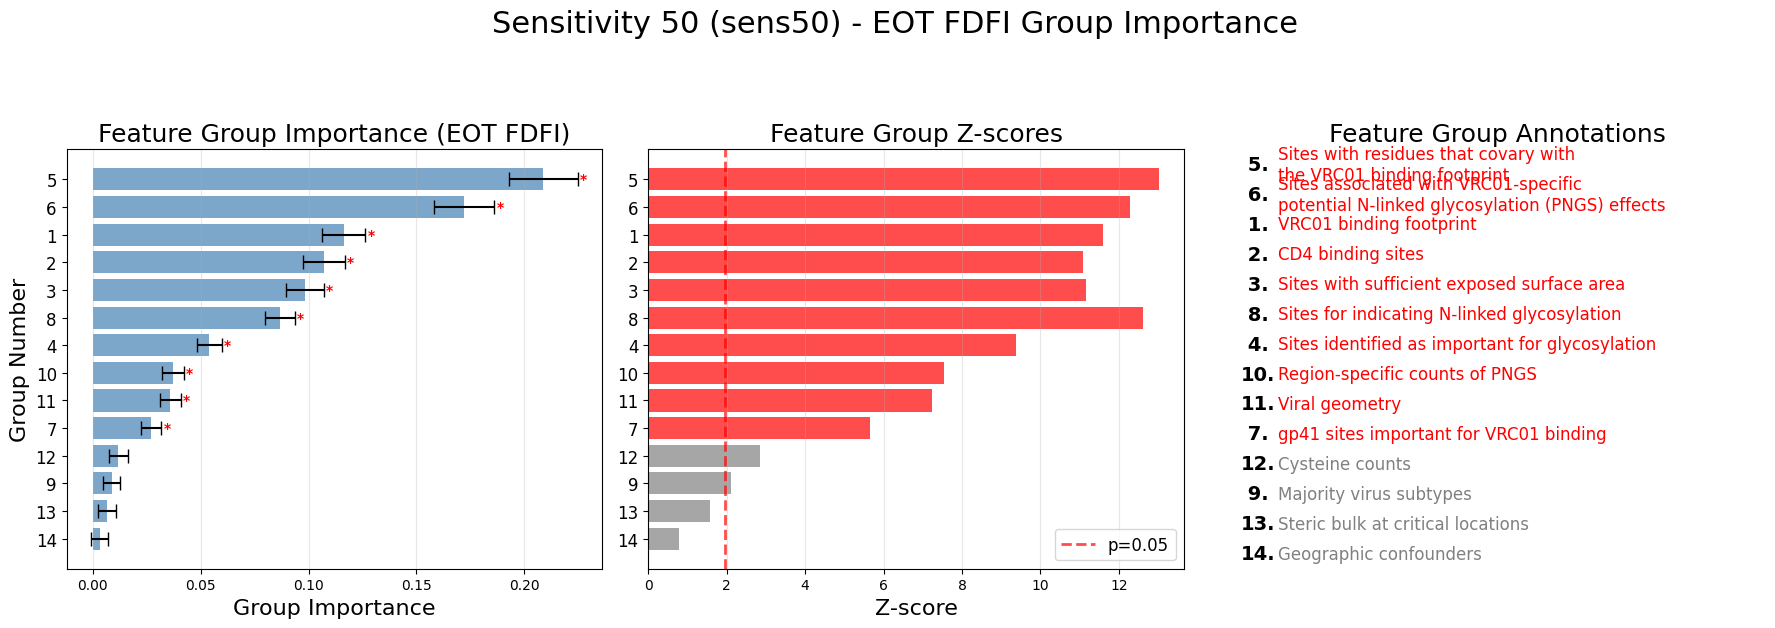

In [11]:
DATASET_LABELS = {
    "sens50": "Sensitivity 50",
    "sens80": "Sensitivity 80",
    "ic50": "IC50 Censored",
}
dataset_label = DATASET_LABELS.get(outcome, outcome)

group_df_sorted = res_df.sort_values("importance", ascending=True).reset_index(drop=True)
group_df_sorted = group_df_sorted.merge(group_mapping, on="group", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 3, 3]})
fig.suptitle(
    f"{dataset_label} ({outcome}) - EOT FDFI Group Importance",
    fontsize=22,
    y=1.04,
)

group_numbers = list(group_df_sorted["group_num"])

ax1 = axes[0]
ax1.barh(
    range(len(group_df_sorted)),
    group_df_sorted["importance"],
    xerr=group_df_sorted["se"],
    error_kw=dict(capsize=5),
    alpha=0.7,
    color="steelblue",
)
ax1.set_yticks(range(len(group_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel("Group Importance", fontsize=16)
ax1.set_title("Feature Group Importance (EOT FDFI)", fontsize=18)
ax1.set_ylabel("Group Number", fontsize=16)
ax1.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    if row["reject_null"]:
        ax1.text(
            row["importance"] + row["se"] + 0.001,
            i,
            "*",
            va="center",
            fontweight="bold",
            color="red",
        )

ax2 = axes[1]
colors = ["red" if reject_null else "gray" for reject_null in group_df_sorted["reject_null"]]
ax2.barh(range(len(group_df_sorted)), group_df_sorted["zscore"], alpha=0.7, color=colors)
ax2.set_yticks(range(len(group_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel("Z-score", fontsize=16)
ax2.set_title("Feature Group Z-scores", fontsize=18)
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(x=1.96, color="red", linestyle="--", linewidth=2, alpha=0.7, label="p=0.05")
ax2.legend(fontsize=12)

ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(group_df_sorted) - 0.5)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    group_name = row["group"]
    display_name = row["description"] if pd.notna(row["description"]) else group_name
    text_color = "red" if row["reject_null"] else "gray"

    ax3.text(
        0.02,
        i,
        f"{int(row['group_num']):2d}.",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color="black",
    )
    ax3.text(
        0.09,
        i,
        display_name,
        va="center",
        ha="left",
        fontsize=12,
        color=text_color,
    )

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title("Feature Group Annotations", fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Ranked group-level result check

The final printout sorts `res_df` by z-score and provides a short ranked check of the group-level results. This is useful when reconciling the notebook with manuscript text because it reports the current run's importance estimates, standard errors, z-scores, and Bonferroni rejection count in one place.


In [12]:
print("=== Current ranked group-level results ===")
print(f"{'Group':<20} {'Importance':>12} {'SE':>10} {'Z-score':>10} {'Significant':>12}")
print("-" * 70)
for _, row in res_df.sort_values("zscore", ascending=False).iterrows():
    sig = "***" if row["reject_null"] else ""
    print(f"{row['group']:<20} {row['importance']:>12.4f} {row['se']:>10.4f} {row['zscore']:>10.2f} {sig:>12}")

n_sig = res_df["reject_null"].sum()
print(f"\nSignificant groups: {n_sig}/{len(res_df)} (Bonferroni alpha=0.05)")
print(f"Z-score range: {res_df['zscore'].min():.2f} to {res_df['zscore'].max():.2f}")


=== Current ranked group-level results ===
Group                  Importance         SE    Z-score  Significant
----------------------------------------------------------------------
covar                      0.2089     0.0161      13.01          ***
pngs_novrc01               0.0867     0.0069      12.61          ***
pngs                       0.1721     0.0140      12.29          ***
vrc01                      0.1163     0.0100      11.59          ***
esa                        0.0983     0.0088      11.15          ***
cd4bs                      0.1073     0.0097      11.09          ***
glyco                      0.0541     0.0058       9.37          ***
sequons                    0.0372     0.0049       7.54          ***
geometry                   0.0359     0.0050       7.23          ***
gp41                       0.0270     0.0048       5.64          ***
cysteines                  0.0119     0.0042       2.85             
subtype                    0.0087     0.0041       2.11   

## Notebook summary

This notebook loads and preprocesses the `sens50` HIV neutralization data, fits a full-data random forest prediction function, initializes `EOTExplainer`, and computes EOT FDFI feature importance in both X-space and Z-space.

At the feature level, the compact summaries report uncertainty for all 832 predictors. At the group level, the notebook aggregates predictors into 14 biological modules, applies Bonferroni-adjusted inference, and produces both a package-style summary output and visualization-ready group mappings.

The group-level X-space summary is the main inferential result for Section 4 because the biological modules are defined in the original predictor space. The visualization objects prepared here support the diagnostic plots and biological interpretation discussed in Section 5.

If this notebook is used as the reproducible source for the manuscript, the group-level text should be synchronized with the current X-space summary output.
